In [42]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Hot Hand Analysis

Goal: Test whether previous shot outcomes affect the probability of making the next shot.

Approach:
- Treat shot outcomes as a time series
- Use autocorrelation (ACF)
- Fit a logistic autoregressive model

## Player Shot Data Preparation
This section loads the selected season’s play-by-play data, filters it to a specific player’s shot attempts, and cleans/sorts the data into the correct chronological order within each game. It then creates a binary “made” variable, removes games with too few shots, and returns a structured dataset ready for analysis (e.g., streaks, hot hand modeling).

In [43]:
# Configuration
SEASON = 2006
DATA_DIR = "pbp"

PLAYER_NAME = "K. Bryant"
PLAYER_ID = 977

SHOT_TYPES = ["Made Shot", "Missed Shot"]
MIN_SHOTS_PER_GAME = 10

In [44]:
def get_data_path(season, data_dir="pbp"):
    return f"{data_dir}/pbp{season}.csv"

def load_and_prepare_player_data(
    season,
    data_dir="pbp",
    player_name=None,
    player_id=None,
    shot_types=("Made Shot", "Missed Shot"),
    min_shots_per_game=1
):
    data_path = get_data_path(season, data_dir)
    df = pd.read_csv(data_path).copy()

    # clean text columns
    for col in ["player", "type", "result", "clock"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

    # keep only shot attempts
    df = df[df["type"].isin(shot_types)].copy()

    # filter by player
    if player_id is not None:
        df = df[df["playerid"] == player_id].copy()
    elif player_name is not None:
        df = df[df["player"] == player_name].copy()
    else:
        raise ValueError("Provide either player_name or player_id.")

    if df.empty:
        raise ValueError(f"No rows found for player in season {season}.")

    # binary shot outcome
    df["made"] = (df["result"] == "Made").astype(int)

    # convert clock to seconds remaining
    clock_parts = df["clock"].str.extract(r"PT(\d+)M([\d\.]+)S")
    df["clock_sec"] = clock_parts[0].astype(float) * 60 + clock_parts[1].astype(float)

    # sort within each game
    df = df.sort_values(
        ["gameid", "period", "clock_sec"],
        ascending=[True, True, False]
    ).reset_index(drop=True)

    # minimum shots per game
    shots_per_game = df.groupby("gameid").size()
    valid_games = shots_per_game[shots_per_game >= min_shots_per_game].index
    df = df[df["gameid"].isin(valid_games)].copy()

    # add season column if needed
    df["season"] = season

    return df


def build_ar_dataframe(
    player_df: pd.DataFrame,
    p: int = 3,
    rolling_window: int | None = None,
    min_shots_per_game: int = None,
) -> pd.DataFrame:
    """
    Constructs a separate AR-ready DataFrame from the raw player shot log.

    For each game:
      - Computes a FG% series per shot (cumulative by default, or rolling window).
      - Numbers shots sequentially within the game.
      - Creates p lag columns of the FG% series.
      - Drops the first p rows of every game (no full lag history yet).

    Parameters
    ----------
    player_df       : output of load_and_prepare_player_data
    p               : AR order — how many lagged FG% values to include
    rolling_window  : if set, use a rolling-window FG% instead of cumulative
    min_shots_per_game : override to drop games with fewer than this many shots
                         after lag trimming (defaults to p + 1)

    Returns
    -------
    ar_df : DataFrame with columns
        gameid, shot_num, period, clock_sec, dist,
        fg_pct, fg_pct_lag1 … fg_pct_lag{p}
    """
    if min_shots_per_game is None:
        min_shots_per_game = p + 1

    records = []

    for gameid, game_df in player_df.groupby("gameid"):
        game_df = game_df.reset_index(drop=True)
        n = len(game_df)

        if n < min_shots_per_game:
            continue

        # ── FG% series ────────────────────────────────────────────────────────
        if rolling_window is not None:
            fg_pct = (
                game_df["made"]
                .rolling(window=rolling_window, min_periods=1)
                .mean()
            )
        else:
            fg_pct = game_df["made"].expanding().mean()  # cumulative

        # ── Lag features ──────────────────────────────────────────────────────
        for i in range(p, n):
            row = {
                "gameid":    gameid,
                "shot_num":  i,                          # 0-indexed within game
                "period":    game_df["period"].iloc[i],
                "clock_sec": game_df["clock_sec"].iloc[i],
                "dist":      game_df.get("dist", pd.Series([np.nan] * n)).iloc[i],
                "fg_pct":    fg_pct.iloc[i],             # target
            }
            for lag in range(1, p + 1):
                row[f"fg_pct_lag{lag}"] = fg_pct.iloc[i - lag]

            records.append(row)

    ar_df = (
        pd.DataFrame(records)
        .dropna(subset=["fg_pct"] + [f"fg_pct_lag{l}" for l in range(1, p + 1)])
        .reset_index(drop=True)
    )

    return ar_df

In [45]:
df = load_and_prepare_player_data(
    season=SEASON,
    data_dir=DATA_DIR,
    player_name=PLAYER_NAME,
    player_id=PLAYER_ID,
    shot_types=SHOT_TYPES,
    min_shots_per_game=MIN_SHOTS_PER_GAME
)

made_per_game = df.groupby("gameid")["made"].sum()

print("Season:", SEASON)
print("Player:", df["player"].iloc[0])
print("Player ID:", df["playerid"].iloc[0])
print("Rows:", len(df))
print("Games:", df["gameid"].nunique())
print("Most Made Shots in a Game:", int(made_per_game.max()))
df.head()

Season: 2006
Player: K. Bryant
Player ID: 977
Rows: 2318
Games: 87
Most Made Shots in a Game: 28


,gameid,period,clock,h_pts,a_pts,team,playerid,player,type,subtype,result,x,y,dist,desc,season,made,clock_sec
0,20500016,1,PT10M43.00S,0.0,0.0,LAL,977,K. Bryant,Missed Shot,Driving Layup Shot,Missed,0,0,0,MISS Bryant Driving Layup,2006,0,643.0
1,20500016,1,PT09M56.00S,6.0,5.0,LAL,977,K. Bryant,Made Shot,Jump Shot,Made,79,199,21,Bryant 21' Jump Shot (2 PTS) (Parker 1 AST),2006,1,596.0
2,20500016,1,PT08M19.00S,8.0,10.0,LAL,977,K. Bryant,Made Shot,Turnaround Jump Shot,Made,-104,76,13,Bryant 13' Turnaround Jump Shot (4 PTS),2006,1,499.0
3,20500016,1,PT07M32.00S,10.0,12.0,LAL,977,K. Bryant,Made Shot,Jump Shot,Made,151,61,16,Bryant 16' Jump Shot (6 PTS) (George 1 AST),2006,1,452.0
4,20500016,1,PT07M02.00S,12.0,14.0,LAL,977,K. Bryant,Made Shot,Reverse Layup Shot,Made,0,0,0,Bryant Reverse Layup (8 PTS) (Parker 2 AST),2006,1,422.0


In [46]:
def find_players(season, search_text, data_dir="pbp"):
    data_path = get_data_path(season, data_dir)
    df = pd.read_csv(data_path, usecols=["playerid", "player"]).drop_duplicates()
    df["player"] = df["player"].astype(str).str.strip()
    result = df[df["player"].str.contains(search_text, case=False, na=False)]
    return result.sort_values("player").reset_index(drop=True)

find_players(SEASON, "jack")

,playerid,player
0,1517,B. Jackson
1,101127,J. Jack
2,754,J. Jackson
3,1983,J. Jackson
4,2739,L. Jackson
5,1531,M. Jackson
6,1536,S. Jackson


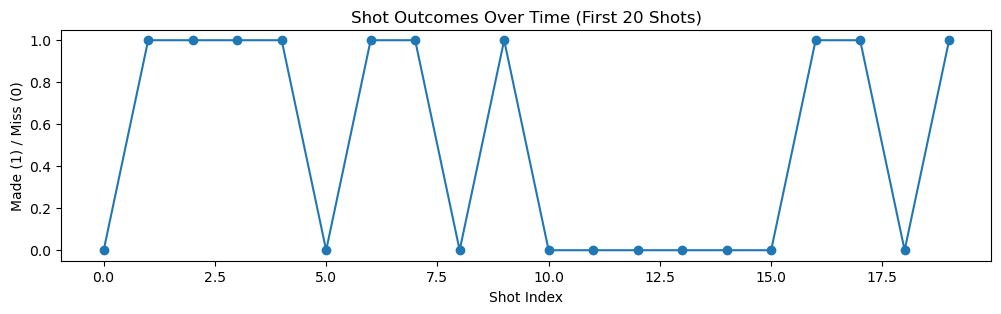

In [47]:
plt.figure(figsize=(12, 3))
plt.plot(df["made"].values[:20], marker='o', linestyle='-')
plt.title("Shot Outcomes Over Time (First 20 Shots)")
plt.xlabel("Shot Index")
plt.ylabel("Made (1) / Miss (0)")
plt.show()

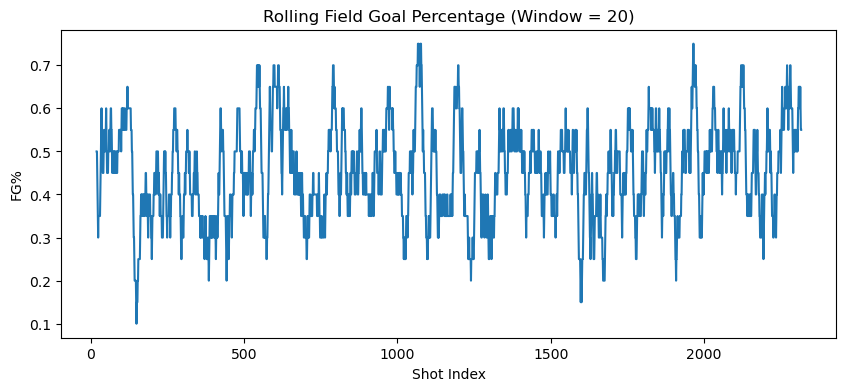

In [48]:
df["rolling_fg"] = df["made"].rolling(window=20).mean()

plt.figure(figsize=(10, 4))
plt.plot(df["rolling_fg"])
plt.title("Rolling Field Goal Percentage (Window = 20)")
plt.xlabel("Shot Index")
plt.ylabel("FG%")
plt.show()

# Initial AR/MR Models
We will first try fitting a basic AR model by hand to see if we can predict the shooting percentage of a player as time goes on


     gameid  shot_num  period  clock_sec  dist    fg_pct  fg_pct_lag1  \
0  22200002         3       1      324.0     3  0.250000     0.000000   
1  22200002         4       1       62.0     0  0.200000     0.250000   
2  22200002         5       1        8.2     4  0.166667     0.200000   
3  22200002         6       2      690.0     1  0.285714     0.166667   
4  22200002         7       2      630.0    26  0.250000     0.285714   

   fg_pct_lag2  fg_pct_lag3  
0     0.000000         0.00  
1     0.000000         0.00  
2     0.250000         0.00  
3     0.200000         0.25  
4     0.166667         0.20  


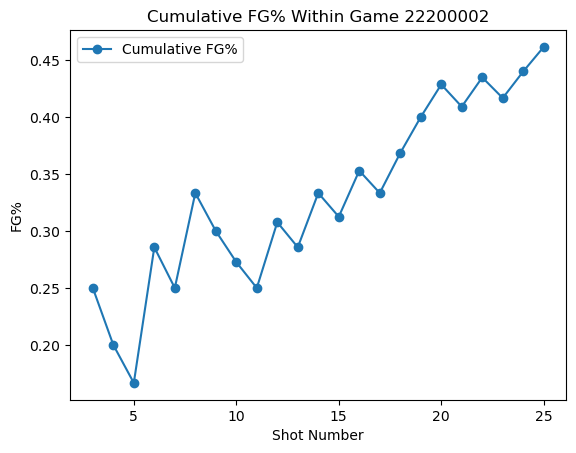

In [49]:
df = load_and_prepare_player_data(season=2023, player_name="L. James")
ar_df = build_ar_dataframe(df, p=3)
print(ar_df.head())

one_game = ar_df[ar_df['gameid'] == 22200002]



plt.plot(one_game['shot_num'], one_game['fg_pct'], marker='o', label='Cumulative FG%')
plt.xlabel('Shot Number')
plt.ylabel('FG%')
plt.title(f'Cumulative FG% Within Game 22200002')
plt.legend()
plt.show()

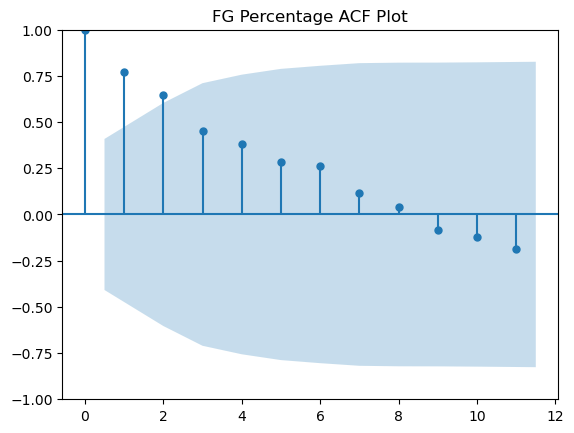

In [50]:
plot_acf(one_game['fg_pct'], title = 'FG Percentage ACF Plot')
plt.show();

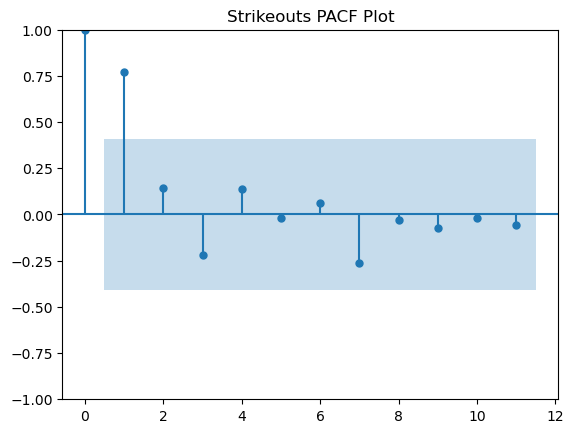

In [51]:
plot_pacf(one_game['fg_pct'], title = 'Strikeouts PACF Plot')
plt.show();

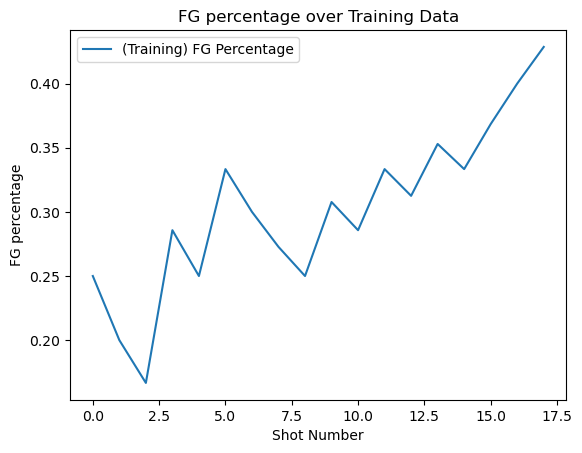

In [58]:
# Split into training and test sets; since we are looking at time series; we are NOT randomly splitting the data
# Take instead the first 80% for the training, then we'll see if the first 80% of MLB history can be used to predict the next 20%
train_size = int(.8 * len(one_game))
train_data = one_game[:train_size]
test_data = one_game[train_size:]

X_train = np.array(train_data['fg_pct_lag1']).reshape(-1,1)

# put the y feature (the current fg_pct) in arrays
y_train = np.array(train_data['fg_pct']).reshape(-1,1)
y_test = np.array(test_data['fg_pct']).reshape(-1,1)

# visualize the time series
plt.plot(train_data['fg_pct'], label='(Training) FG Percentage')
plt.xlabel('Shot Number')
plt.ylabel('FG percentage')
plt.legend()
plt.title('FG percentage over Training Data')
plt.show();

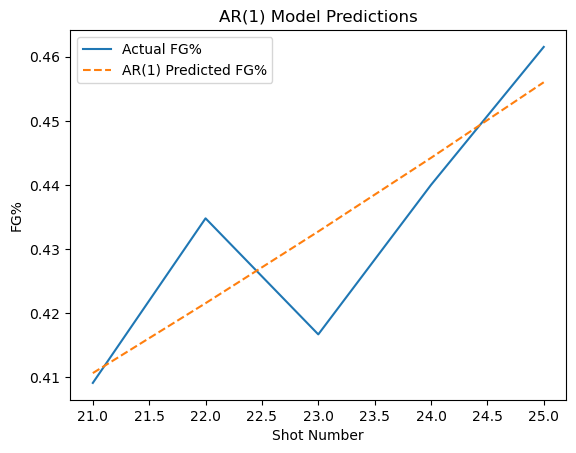

In [59]:
# Predictions
y_pred = []
w = np.dot(np.linalg.inv(np.dot(X_train.T, X_train)), np.dot(X_train.T, y_train))

start = np.array(train_data['fg_pct_lag1'].iloc[-1]).reshape(-1, 1)

for i in range(len(test_data)):
    y_pred.append(w.T.dot(start).flatten()[0])
    start = np.array(y_pred[i]).reshape(-1, 1)  # feed prediction back in

pred_data = pd.DataFrame({
    'shot_num': test_data['shot_num'].values,
    'fg_pct_pred': y_pred
})

plt.plot(test_data['shot_num'].values, test_data['fg_pct'].values, label='Actual FG%')
plt.plot(pred_data['shot_num'], pred_data['fg_pct_pred'], label='AR(1) Predicted FG%', linestyle='--')
plt.xlabel('Shot Number')
plt.ylabel('FG%')
plt.legend()
plt.title('AR(1) Model Predictions')
plt.show()

# Summary
Not nearly enough data per game, so lets build a rolling field goal percentage for the whole season

In [103]:
df = load_and_prepare_player_data(season=2016, player_name="S. Curry")


def build_shot_ar_dataframe(player_df, p=3):
    records = []

    for gameid, game_df in player_df.groupby("gameid"):
        game_df = game_df.reset_index(drop=True)
        n = len(game_df)

        if n <= p:
            continue

        for i in range(p, n):
            row = {
                "gameid": gameid,
                "shot_num": i,
                "made": game_df["made"].iloc[i],
            }

            for lag in range(1, p+1):
                row[f"made_lag{lag}"] = game_df["made"].iloc[i - lag]

            records.append(row)

    return pd.DataFrame(records).reset_index(drop=True)


p = 3
ar_df = build_shot_ar_dataframe(df, p=p)

In [104]:
games = ar_df["gameid"].unique()
split_idx = int(0.8 * len(games))

train_games = games[:split_idx]
test_games  = games[split_idx:]

train_df = ar_df[ar_df["gameid"].isin(train_games)].copy()
test_df  = ar_df[ar_df["gameid"].isin(test_games)].copy()



In [105]:
import numpy as np

lag_cols = [f"made_lag{i}" for i in range(1, p+1)]

X = train_df[lag_cols].values
y = train_df["made"].values.reshape(-1, 1)

# add intercept
X = np.hstack([np.ones((X.shape[0], 1)), X])

In [106]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def train_logistic_regression(X, y, lr=0.05, epochs=2000):
    n, d = X.shape
    w = np.zeros((d, 1))

    for epoch in range(epochs):
        z = X @ w
        p_hat = sigmoid(z)

        gradient = (X.T @ (p_hat - y)) / n
        w -= lr * gradient

        if epoch % 200 == 0:
            loss = -np.mean(
                y * np.log(p_hat + 1e-8) +
                (1 - y) * np.log(1 - p_hat + 1e-8)
            )
            print(f"Epoch {epoch}, Loss: {loss:.4f}")

    return w


w = train_logistic_regression(X, y)


Epoch 0, Loss: 0.6931
Epoch 200, Loss: 0.6914
Epoch 400, Loss: 0.6908
Epoch 600, Loss: 0.6906
Epoch 800, Loss: 0.6905
Epoch 1000, Loss: 0.6905
Epoch 1200, Loss: 0.6904
Epoch 1400, Loss: 0.6904
Epoch 1600, Loss: 0.6904
Epoch 1800, Loss: 0.6904


In [107]:
y_pred_prob = []
y_pred = []

for gameid, game_df in test_df.groupby("gameid"):
    game_df = game_df.reset_index(drop=True)

    # initialize state from FIRST row of this game
    state = game_df[lag_cols].iloc[0].values.astype(float)

    for i in range(len(game_df)):
        x = np.concatenate([[1], state]).reshape(1, -1)
        prob = sigmoid(x @ w)[0, 0]

        y_pred_prob.append(prob)

        pred = 1 if prob > 0.5 else 0
        y_pred.append(pred)

        # update AR state
        state = np.roll(state, 1)
        state[0] = prob  # smoother than using pred
        
test_df = test_df.copy()
test_df["pred_prob"] = y_pred_prob
test_df["pred"] = y_pred

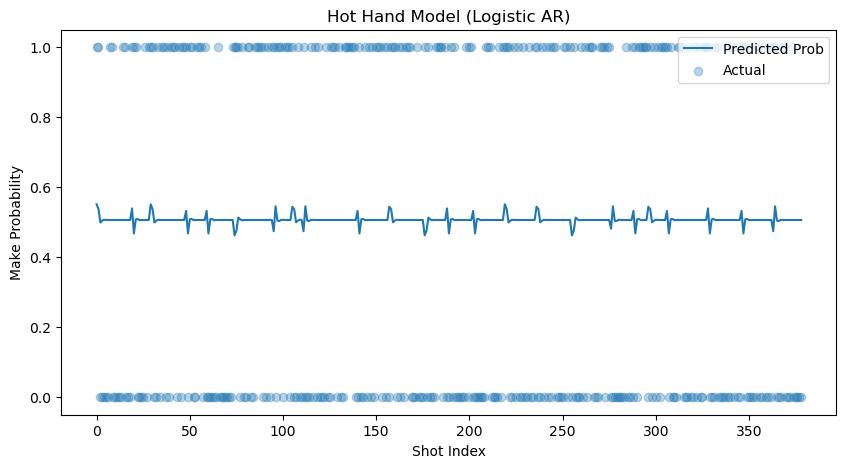

[[ 0.1768687 ]
 [-0.04752792]
 [-0.27981957]
 [ 0.02843252]]


In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(test_df["pred_prob"].values, label="Predicted Prob")
plt.scatter(range(len(test_df)), test_df["made"], alpha=0.3, label="Actual")

plt.xlabel("Shot Index")
plt.ylabel("Make Probability")
plt.title("Hot Hand Model (Logistic AR)")
plt.legend()
plt.show()
print(w)

In [109]:
baseline = train_df["made"].mean()
print("Baseline FG%:", baseline)

Baseline FG%: 0.507537688442211


# Hot Hand Analysis

Goal: Test whether previous shot outcomes affect the probability of making the next shot.

Approach:
- Treat shot outcomes as a time series
- Use autocorrelation (ACF)
- Fit a logistic autoregressive model

## Basic Summary

The mean represents shooting percentage.

If shots are independent, we should not see strong dependence across time.

In [ ]:
print("Mean:", df["made"].mean())
print("Variance:", df["made"].var())

## Feature Engineering

We create lag variables to capture previous shot outcomes within each game.

These will be used to test whether recent shots influence future performance.

In [ ]:
# Create lagged shot outcomes within each game
for lag in range(1, 4):
    df[f"lag{lag}"] = df.groupby("gameid")["made"].shift(lag)

# Drop rows where lags are missing
model_df = df.dropna(subset=["lag1", "lag2", "lag3"]).copy()

# Convert to int
for lag in range(1, 4):
    model_df[f"lag{lag}"] = model_df[f"lag{lag}"].astype(int)

print("Modeling rows:", len(model_df))
model_df[["gameid", "made", "lag1", "lag2", "lag3"]].head()

In [ ]:
# Conditional probabilities
hot_hand_table = pd.crosstab(model_df["lag1"], model_df["made"], normalize="index")
print(hot_hand_table)

# Plot
probs = hot_hand_table[1]

plt.figure(figsize=(6, 4))
probs.plot(kind="bar")
plt.xticks([0, 1], ["Prev Miss", "Prev Make"], rotation=0)
plt.ylabel("P(Make)")
plt.title("Conditional Make Probability")
plt.show()

While the ACF analysis suggests little linear dependence in shot outcomes, it may fail to detect subtle probabilistic effects due to the binary nature of the data. 

To more directly test for a hot hand effect, we estimate a logistic autoregressive model, where the probability of making a shot depends on recent shot outcomes within the same game.

## Logistic Autoregressive Model

We model the probability of making a shot as a function of recent shot history.

This allows us to directly test for a hot hand effect.

In [ ]:
# Logistic autoregressive model
logit_model = smf.glm(
    formula="made ~ lag1 + lag2 + lag3",
    data=model_df,
    family=sm.families.Binomial()
).fit(cov_type="cluster", cov_kwds={"groups": model_df["gameid"]})

print(logit_model.summary())

## Interpretation

- lag1: effect of previous shot
- lag2, lag3: longer memory effects

If coefficients are:
- Positive = hot hand
- Near zero = independence
- Negative = regression to the mean

In this case:
- lag1 is slightly negative and not significant
- lag2 is near zero
- lag3 is slightly negative

This suggests little to no evidence of a hot hand effect.

In [ ]:
# Predictions
model_df["pred_prob"] = logit_model.predict(model_df)

model_df[["made", "lag1", "lag2", "lag3", "pred_prob"]].head()

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(model_df["pred_prob"].values[:200], label="Predicted Prob")
plt.plot(model_df["made"].values[:200], alpha=0.5, label="Actual Outcome")
plt.legend()
plt.title("Predicted Probability vs Actual Outcomes")
plt.show()

## Autocorrelation (ACF)

We test whether shot outcomes are linearly dependent on previous shots.

If a hot hand exists, we expect positive autocorrelation at small lags.

In [ ]:
# ACF of shot outcomes (all games, ordered correctly)
series = model_df["made"]

plt.figure(figsize=(8, 4))
plot_acf(df["made"])
plt.title("ACF of Shot Outcomes (Kobe Bryant)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

ACF may fail to detect dependence because the data is binary.

We therefore use a logistic autoregressive model next.

## Partial Autocorrelation (PACF)

PACF helps isolate the direct effect of each lag.

In [ ]:
plt.figure(figsize=(8, 4))
plot_pacf(df["made"])
plt.title("PACF of Shot Outcomes (Kobe Bryant)")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.show()

In [ ]:
# Convert to class predictions
model_df["pred_class"] = (model_df["pred_prob"] >= 0.5).astype(int)

# Metrics
auc = roc_auc_score(model_df["made"], model_df["pred_prob"])
ll = log_loss(model_df["made"], model_df["pred_prob"])
acc = accuracy_score(model_df["made"], model_df["pred_class"])

print(f"ROC-AUC: {auc:.4f}")
print(f"Log Loss: {ll:.4f}")
print(f"Accuracy: {acc:.4f}")

In [ ]:
print("Lag 1 correlation:", np.corrcoef(df["made"][:-1], df["made"][1:])[0,1])

In [ ]:
# plot diagnostics (residuals) ?
# mean absolute error (mae) ?
# root mean squared error (rmse) ?